## Exercise 0.1: Build a periodic grid and probe periodicity

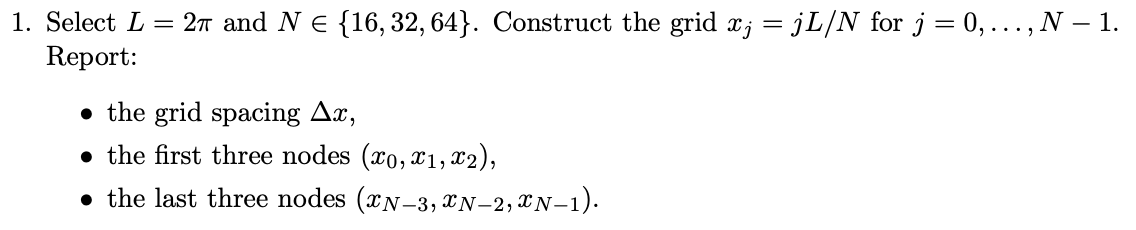

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

In [2]:
# Constructing grid points

L = 2*np.pi
N = [16,32,64]
arrays = []

for size in N:
    x_j = np.zeros(size)
    print("Grid spacing ∆x: {}".format(L/size))
    
    for i in range(0,size):
        x_j[i] = i*L/size
        
    arrays.append(x_j)
    
    print("First three nodes: ",x_j[0],x_j[1],x_j[2])
    print("Last three nodes: ",x_j[size-3],x_j[size-2],x_j[size-1])

    print("\n")

A16 = arrays[0]
A32 = arrays[1]
A64 = arrays[2]

array_dict = {16:A16, 32:A32, 64:A64}

Grid spacing ∆x: 0.39269908169872414
First three nodes:  0.0 0.39269908169872414 0.7853981633974483
Last three nodes:  5.105088062083414 5.497787143782138 5.890486225480862


Grid spacing ∆x: 0.19634954084936207
First three nodes:  0.0 0.19634954084936207 0.39269908169872414
Last three nodes:  5.6941366846315 5.890486225480862 6.086835766330224


Grid spacing ∆x: 0.09817477042468103
First three nodes:  0.0 0.09817477042468103 0.19634954084936207
Last three nodes:  5.988660995905543 6.086835766330224 6.1850105367549055




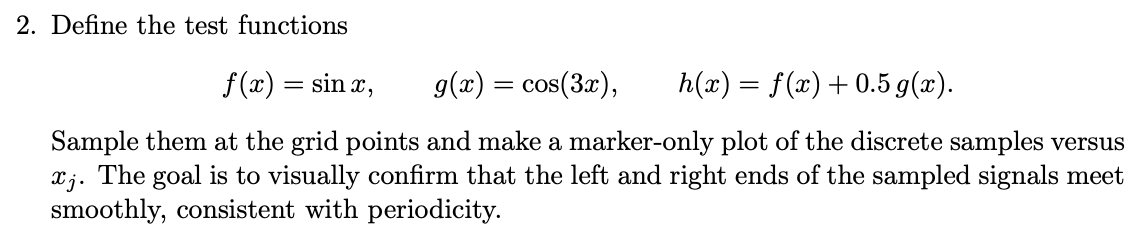

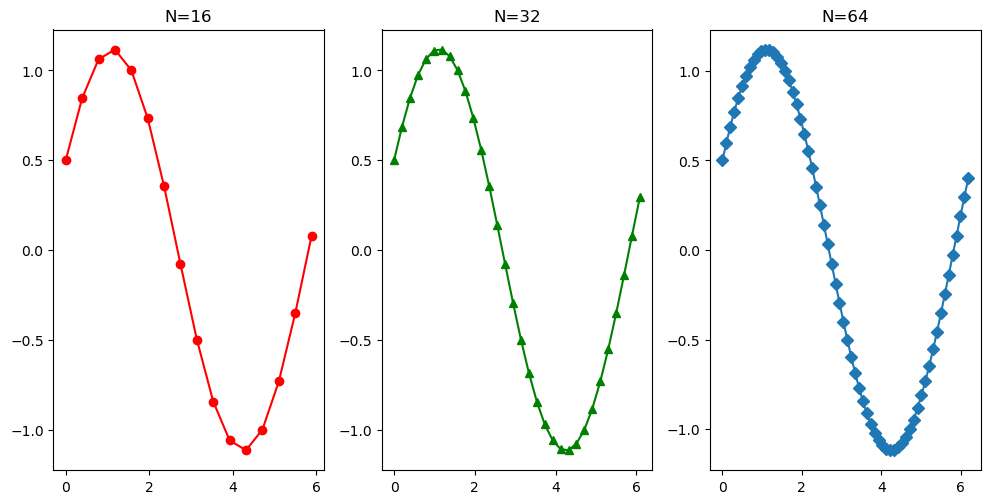

In [3]:
def f(x):
    return np.sin(x)
def g(x):
    return np.cos(x)
def h(x):
    return f(x) + 0.5*g(x)

grid = []

for array in array_dict.values():
    grid.append(list(map(lambda x: h(x), array)))

# Visualization

fig, ax = plt.subplots(1, 3, figsize=(10,5))
fig.tight_layout()

ax[0].plot(A16, grid[0],color = 'r',marker = 'o')
ax[0].set_title("N=16")

ax[1].plot(A32, grid[1],color = 'g',marker='^', label='N=32')
ax[1].set_title("N=32")

ax[2].plot(A64, grid[2],marker='D', label='N=64')
ax[2].set_title("N=64")

plt.show()


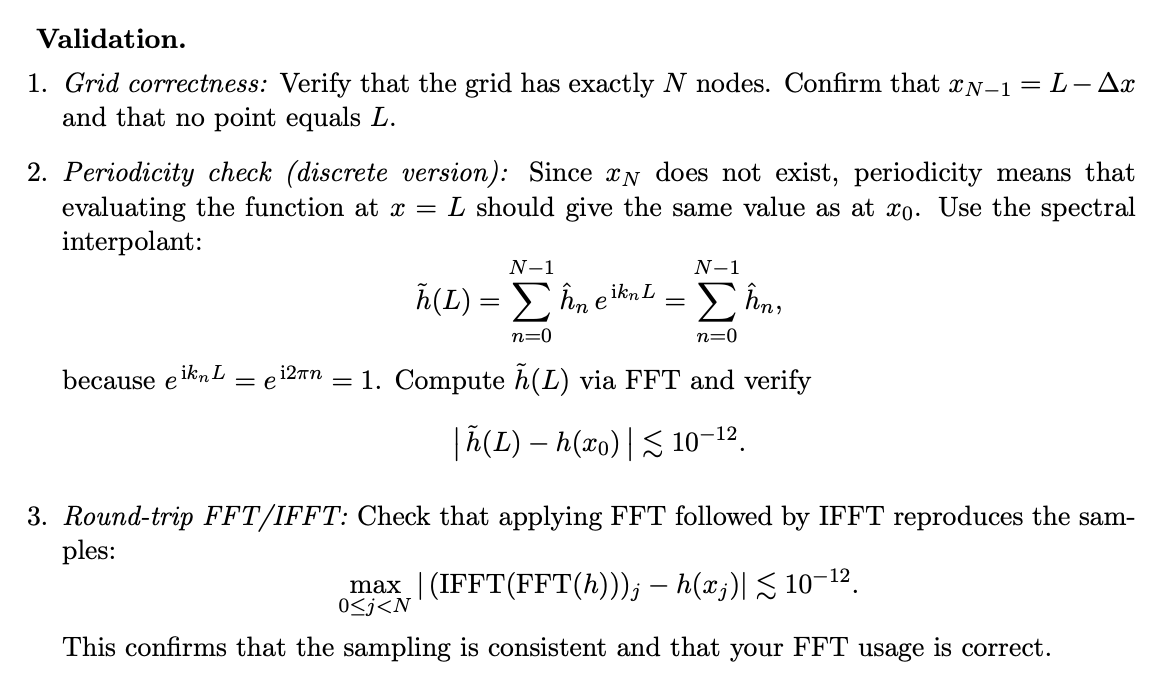

In [4]:
# Validation

# Task 1: Grid Correctness
for size, array in array_dict.items():
    print("N={} and length of corresponding array is {}".format(size, len(array)))
print('\n')

# Task 2: Periodicity check (discrete version)

for i,size in enumerate(array_dict):
    h_hat = np.fft.fft(grid[i])

    # Interpolant
    h_tilda_L = (np.sum(h_hat))/size # (Fix suggested by ChatGPT)

    # Original value at x_0
    h_0 = h(array_dict[size][0])

    # Error
    err = np.abs(h_tilda_L - h_0)
    print("Periodicity check with N={}, error is {}".format(size,err),'\n')

# Task 3: Round-trip FFT/IFFT

for i,size in enumerate(array_dict):
    h_hat = np.fft.fft(grid[i])
    diff = np.linalg.norm(np.fft.ifft(h_hat) - grid[i], np.inf)
    print("For N={}, diff is {}".format(size,diff))

N=16 and length of corresponding array is 16
N=32 and length of corresponding array is 32
N=64 and length of corresponding array is 64


Periodicity check with N=16, error is 5.551115123125783e-17 

Periodicity check with N=32, error is 5.551115123125783e-17 

Periodicity check with N=64, error is 5.551115123125783e-17 

For N=16, diff is 2.3551386880256624e-16
For N=32, diff is 2.482534153247273e-16
For N=64, diff is 6.707437923744493e-16


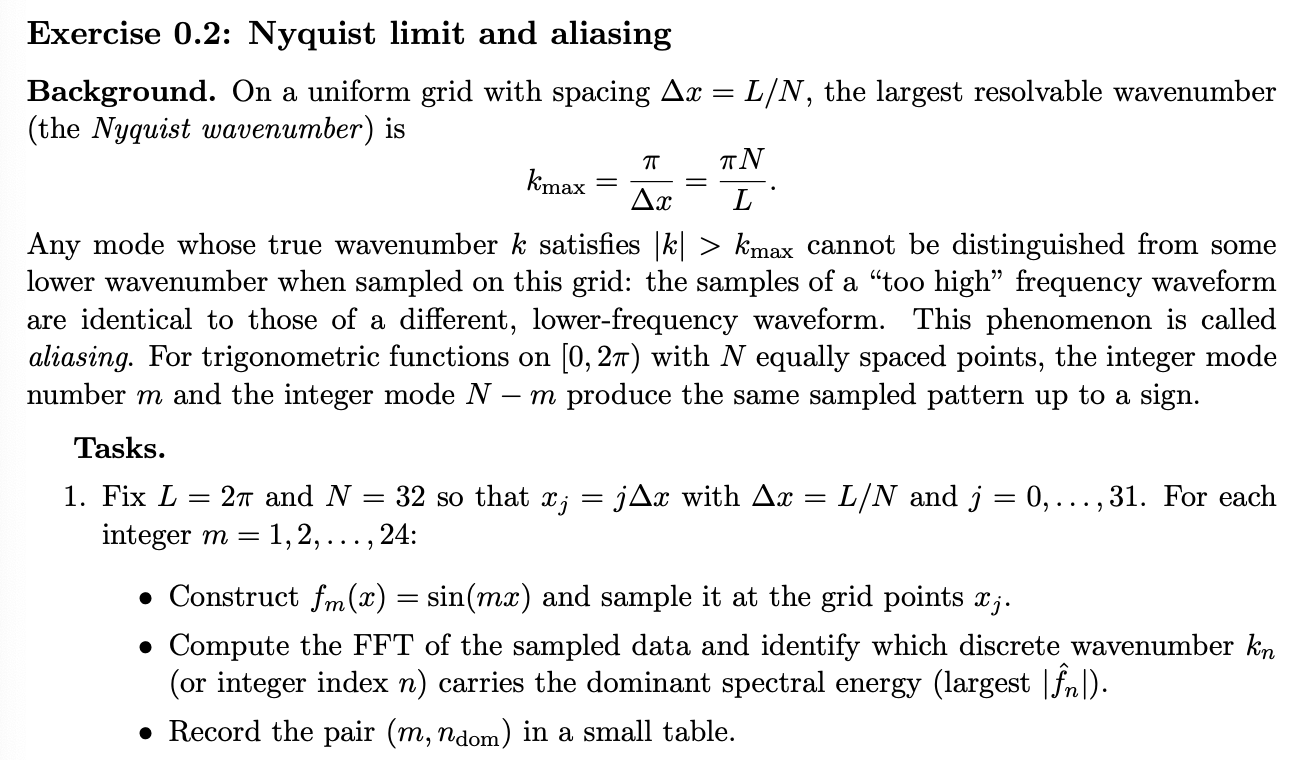

In [5]:
# Task 01

L = 2*np.pi
N = 32
x_j = np.zeros(N)
sampled_array = []
dom_spec_energy_table = pd.DataFrame(columns=['m','n_dom'])

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

for pos,m in enumerate(range(1,25)):
    
    sampled_array.append(list(map(lambda x: np.sin(m*x), x_j)))

    fft_sampled_array = np.fft.fft(sampled_array[pos])
    
    idx = np.argmax(np.abs(fft_sampled_array))
    max_f_hat = np.abs(fft_sampled_array[idx])

    dom_spec_energy_table.loc[len(dom_spec_energy_table)] = [m, idx]


Grid spacing ∆x: 0.19634954084936207


In [6]:
min(17,32-17)
dom_spec_energy_table

# Task 02

# sin (mx_j) and sin(N-m)x_j produce the same sampled waveform (with a minus sign)
# since x_j = j∆x = j. (2π)/N and Nx_j = 2π.j, thus, sin(N-m)x_j is essentially
# -sin(mx_j).

# This could be rephrased using the periodicity of the euler function, as,
# e^i(N-m)x_j = e^-imx_j


,m,n_dom
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,6,6
6,7,7
7,8,8
8,9,9
9,10,10


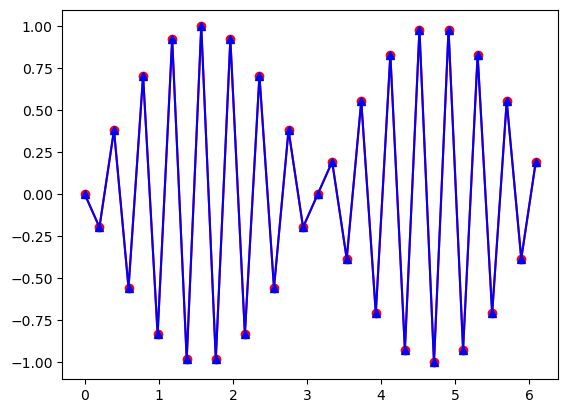

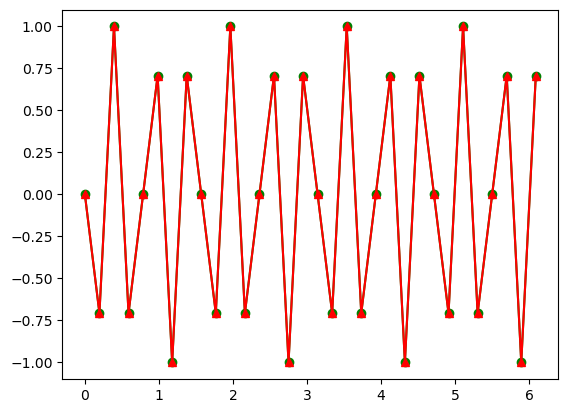

In [7]:
# Task 03

plt.plot(x_j,list(map(lambda x: np.sin(17*x), x_j)),color = 'r',marker = 'o')
plt.plot(x_j,list(map(lambda x: -np.sin(15*x), x_j)),color = 'b',marker = '^')

plt.show()

plt.plot(x_j,list(map(lambda x: np.sin(20*x), x_j)),color = 'g',marker = 'o')
plt.plot(x_j,list(map(lambda x: -np.sin(12*x), x_j)),color = 'r',marker = '^') #Fix

plt.show()

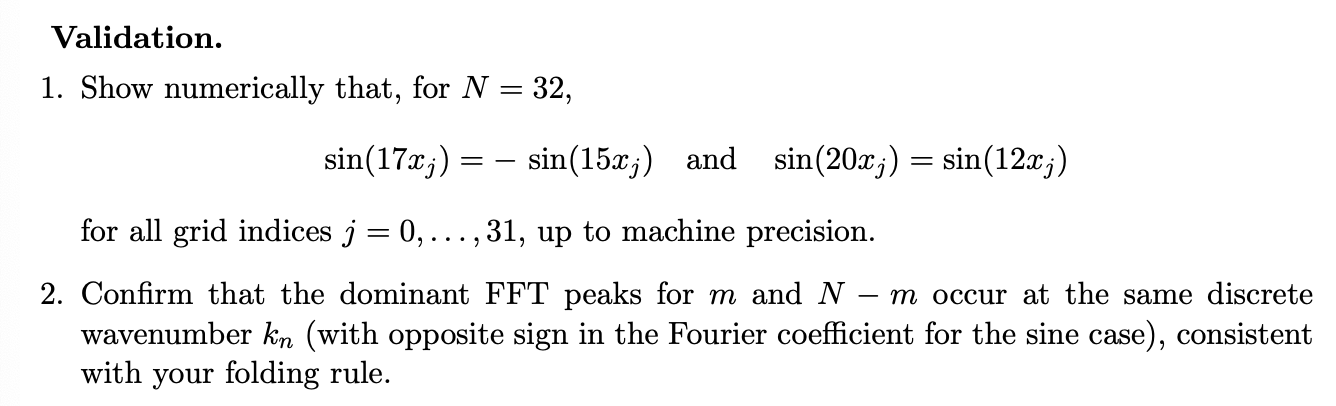

In [8]:
# Validation

# Task 01

diff = np.subtract(list(map(lambda x: np.abs(np.sin(17*x)), x_j)), list(map(lambda x: np.abs(-np.sin(15*x)), x_j)))
print((diff <= 1e-12).all())

diff = np.subtract(list(map(lambda x: np.abs(np.sin(20*x)), x_j)), list(map(lambda x: np.abs(-np.sin(12*x)), x_j)))
print((diff <= 1e-12).all())

# Task 02

delta_x = L/N
freq = np.fft.fftfreq(N, d=delta_x) # fftfreq returns the Fourier Frequencies
k_n = 2*np.pi * freq # L/N is delta x or the grid spacing

print(k_n)


True
True
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.
  -4.  -3.  -2.  -1.]


In [9]:
for idx, data in dom_spec_energy_table.iterrows():
    
    if dom_spec_energy_table.loc[dom_spec_energy_table['m'] == N - data['m'].item(),].empty:
        continue
    
    print(
        "For m={} and N-m={}, dominant peaks are at {} and {}, corresponding wave numbers are {} and {}".format(
        data['m'].item(),
        N-data['m'].item(),
        data['n_dom'].item(),
        int(dom_spec_energy_table.loc[dom_spec_energy_table['m'] == N-data['m'].item(),'n_dom'].values[0]),
        k_n[data['n_dom'].item()],
        k_n[int(dom_spec_energy_table.loc[dom_spec_energy_table['m'] == N-data['m'].item(),'n_dom'].values[0])]
        
    )
         )

For m=8 and N-m=24, dominant peaks are at 8 and 8, corresponding wave numbers are 8.0 and 8.0
For m=9 and N-m=23, dominant peaks are at 9 and 9, corresponding wave numbers are 9.0 and 9.0
For m=10 and N-m=22, dominant peaks are at 10 and 10, corresponding wave numbers are 10.0 and 10.0
For m=11 and N-m=21, dominant peaks are at 11 and 11, corresponding wave numbers are 11.0 and 11.0
For m=12 and N-m=20, dominant peaks are at 12 and 12, corresponding wave numbers are 12.0 and 12.0
For m=13 and N-m=19, dominant peaks are at 13 and 13, corresponding wave numbers are 12.999999999999998 and 12.999999999999998
For m=14 and N-m=18, dominant peaks are at 14 and 14, corresponding wave numbers are 14.000000000000002 and 14.000000000000002
For m=15 and N-m=17, dominant peaks are at 15 and 15, corresponding wave numbers are 15.0 and 15.0
For m=16 and N-m=16, dominant peaks are at 16 and 16, corresponding wave numbers are -16.0 and -16.0
For m=17 and N-m=15, dominant peaks are at 15 and 15, corresp

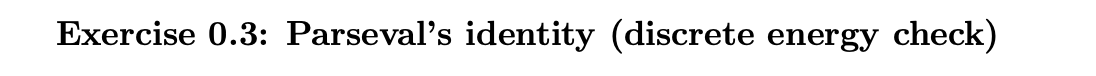
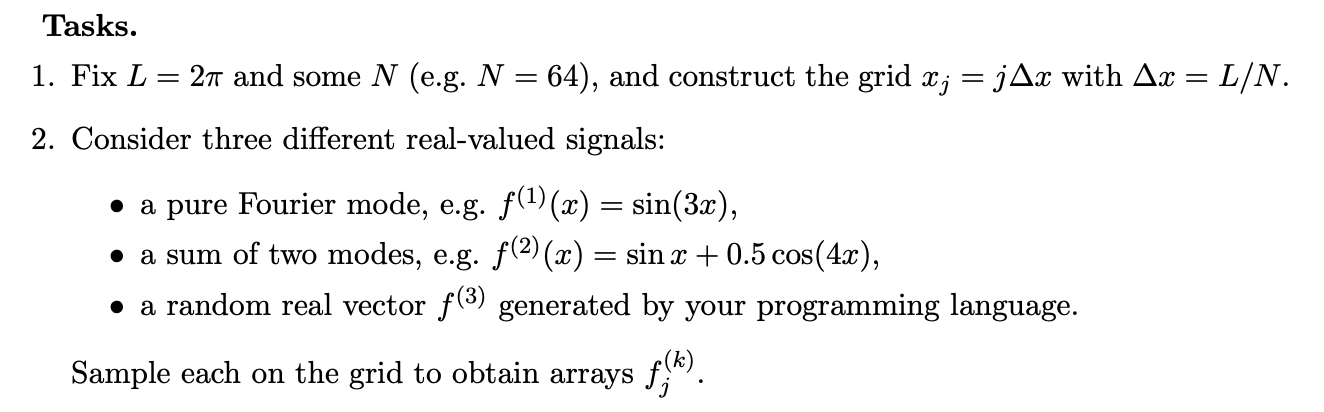
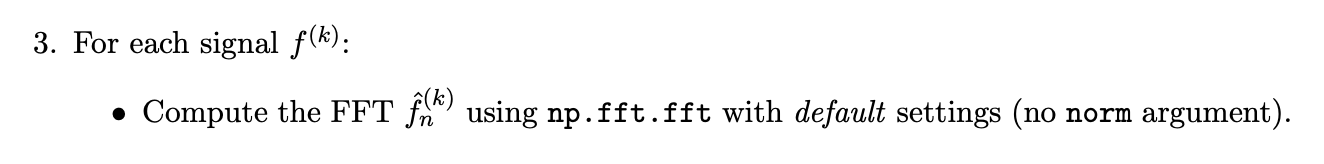
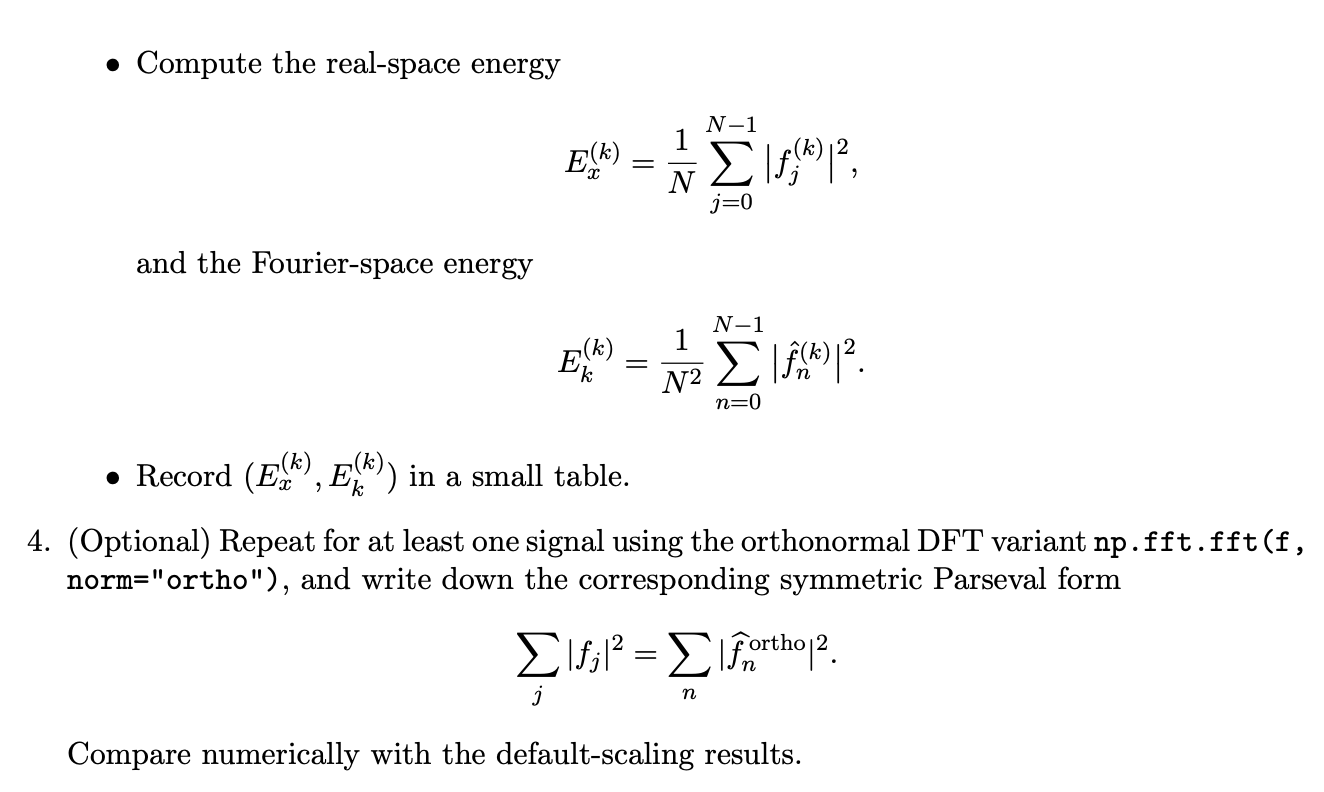

In [47]:
L = 2*np.pi
N = 64
x_j = np.zeros(N)
sampled_array_1,sampled_array_2,sampled_array_3 = [],[],[]

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))


sampled_array_1.append(list(map(lambda x: np.sin(3*x), x_j)))
sampled_array_2.append(list(map(lambda x: np.sin(x) + 0.5*np.cos(4*x), x_j)))
sampled_array_3 = np.random.uniform(low=-1, high=1, size=(64,))

Grid spacing ∆x: 0.09817477042468103


In [48]:
fn_1_hat = np.fft.fft(sampled_array_1)
fn_2_hat = np.fft.fft(sampled_array_2)
fn_3_hat = np.fft.fft(sampled_array_3)

In [49]:
# Real space energy
E_1_x = (1/N)*np.sum(np.square(np.abs(sampled_array_1)))
E_2_x = (1/N)*np.sum(np.square(np.abs(sampled_array_2)))
E_3_x = (1/N)*np.sum(np.square(np.abs(sampled_array_3)))

Ex_k = [E_1_x,E_2_x,E_3_x]

# Fourier space energy
E_1_k = (1/N**2)*np.sum(np.square(np.abs(fn_1_hat)))
E_2_k = (1/N**2)*np.sum(np.square(np.abs(fn_2_hat)))
E_3_k = (1/N**2)*np.sum(np.square(np.abs(fn_3_hat)))

Ek_k = [E_1_k,E_2_k,E_3_k]

energy_table = pd.DataFrame(columns = ['E_x_k','E_k_k','Parseval justified?'])

for real_energy, fourier_energy in zip(Ex_k,Ek_k):
    energy_table.loc[len(energy_table)] = [real_energy, fourier_energy,0]

    
energy_table['Parseval justified?'] = energy_table.apply(
        lambda x: True if np.abs(np.subtract(x['E_x_k'], x['E_k_k'])) <= 1e-12 else False, axis=1)

energy_table


,E_x_k,E_k_k,Parseval justified?
0,0.500000,0.500000,True
1,0.625000,0.625000,True
2,0.338071,0.338071,True


In [50]:
# With norm = "ortho"

fn_1_hat_o = np.fft.fft(sampled_array_1,norm="ortho")
fn_2_hat_o = np.fft.fft(sampled_array_2,norm="ortho")
fn_3_hat_o = np.fft.fft(sampled_array_3,norm="ortho")

# Real space energy
E_1_x_o = np.sum(np.square(np.abs(sampled_array_1)))
E_2_x_o = np.sum(np.square(np.abs(sampled_array_2)))
E_3_x_o = np.sum(np.square(np.abs(sampled_array_3)))

Ex_k_o = [E_1_x,E_2_x,E_3_x]

# Fourier space energy
E_1_k_o = np.sum(np.square(np.abs(fn_1_hat)))
E_2_k_o = np.sum(np.square(np.abs(fn_2_hat)))
E_3_k_o = np.sum(np.square(np.abs(fn_3_hat)))

Ek_k_o = [E_1_k,E_2_k,E_3_k]

energy_table_o = pd.DataFrame(columns = ['E_x_k_o','E_k_k_o','Parseval justified?'])

for real_energy, fourier_energy in zip(Ex_k_o,Ek_k_o):
    energy_table_o.loc[len(energy_table_o)] = [real_energy, fourier_energy,0]

    
energy_table_o['Parseval justified?'] = energy_table_o.apply(
        lambda x: True if np.abs(np.subtract(x['E_x_k_o'], x['E_k_k_o'])) <= 1e-12 else False, axis=1)

energy_table_o


,E_x_k_o,E_k_k_o,Parseval justified?
0,0.500000,0.500000,True
1,0.625000,0.625000,True
2,0.338071,0.338071,True


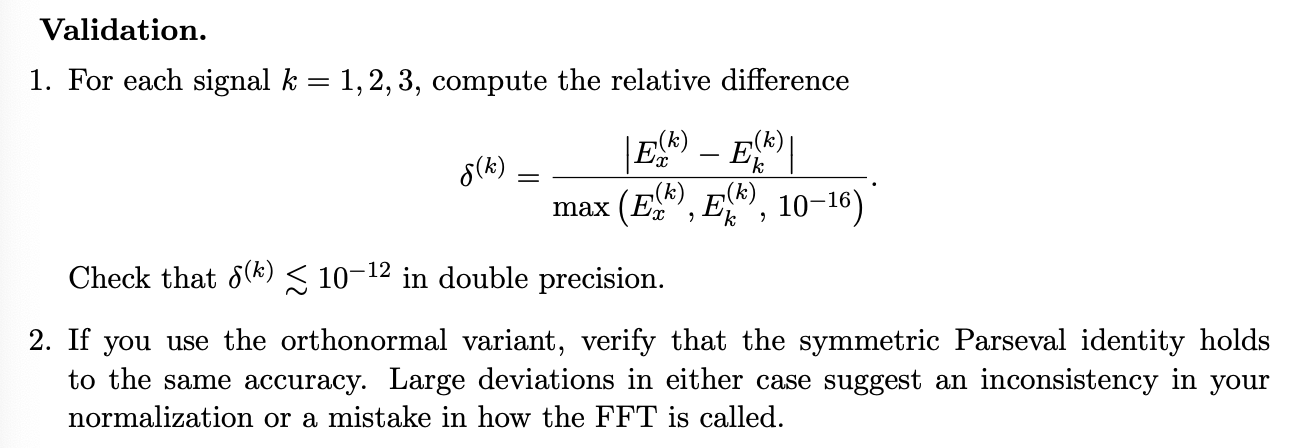

In [60]:
energy_table['delta_k'] = energy_table.apply(
        lambda x: True if np.abs(np.subtract(x['E_x_k'], x['E_k_k']))/max(x['E_x_k'],x['E_x_k'],1e-16) <= 1e-12 else False, axis=1)
energy_table

,E_x_k,E_k_k,Parseval justified?,delta_k
0,0.500000,0.500000,True,True
1,0.625000,0.625000,True,True
2,0.338071,0.338071,True,True


In [61]:
energy_table_o['delta_k'] = energy_table_o.apply(
        lambda x: True if np.abs(np.subtract(x['E_x_k_o'], x['E_k_k_o']))/max(x['E_x_k_o'],x['E_x_k_o'],1e-16) <= 1e-12 else False, axis=1)
energy_table_o

,E_x_k_o,E_k_k_o,Parseval justified?,delta_k
0,0.500000,0.500000,True,True
1,0.625000,0.625000,True,True
2,0.338071,0.338071,True,True
